<a href="https://colab.research.google.com/github/germionna1990/hw5_mlops_dvoryashina_irina/blob/main/%22HW5_MLOps_%D0%94%D0%B2%D0%BE%D1%80%D1%8F%D1%88%D0%B8%D0%BD%D0%B0_%D0%98%D1%80%D0%B8%D0%BD%D0%B0_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Домашнее задание 5.  Обеспечение воспроизводимости эксперимента
Дворяшина ИА

In [1]:
%%capture
!pip install feast psycopg psycopg_pool pandas scikit-learn -qqq
!pip install gdown tqdm -qqq
!pip install marimo -qqq
from tqdm import tqdm
import psycopg
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
!apt-get update -qq > /dev/null
!apt-get install -y yamllint > /dev/null

In [2]:
!pip install diagrams -q

In [3]:
# from google.colab import userdata
# import os
# os.environ["tunatoken"] = userdata.get('tuna')
# !curl -sSLf https://get.tuna.am | sh >/dev/null
# !tuna config save-token $tunatoken

## 1. Выяснить ограничения традиционных ноутбуков Collab при разработке ML-систем по сравнению с [Marimo](https://github.com/marimo-team/marimo)


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=zIad_EXtUcVa)*



In [4]:
# print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, добавьте ?access_token=password, нажмите Enter")
# !sleep 5 && marimo tutorial ui --port 8010 --host 0.0.0.0 --headless --token-password password & tuna http 8010 & wait

Ваши выводы об удобстве работы с Marimo

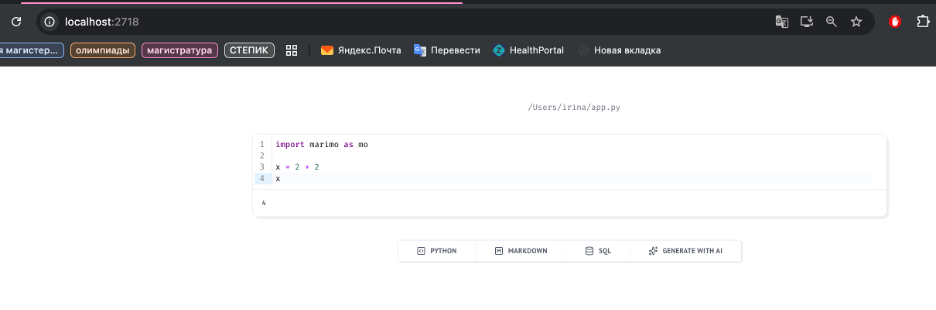![image.png](
  
)

запустила Маримо

Маримо удобнее для воспроизводимости и чистоты кода, а Колаб и Юпитер — для обучения.

В маримо нет проблемы с окнами, это питонский код где строчка за строчкой отрабатывает программа

Маримо удобнее интегрировать с гитом

## 2. Обеспечить воспроизводимость эксперимента, используя DVC/MLflow

* Инициализируйте Git и DVC.
* Добавьте небольшой датасет (например, Iris, Titanic или Wine).
* **Не храните данные в Git, используйте DVC**.
* Создайте пайплайн DVC минимум в две стадии.


*Ожидаемый артефакт: bash-скрипт в [ячейке](#scrollTo=HhN_l9aNrTaV)*



**Я не сразу поняла что нужно было делать в коллабе и сделала локально, приложу ниже крины и короткое описание что сделала**

Создала репозиторий и установила DVC

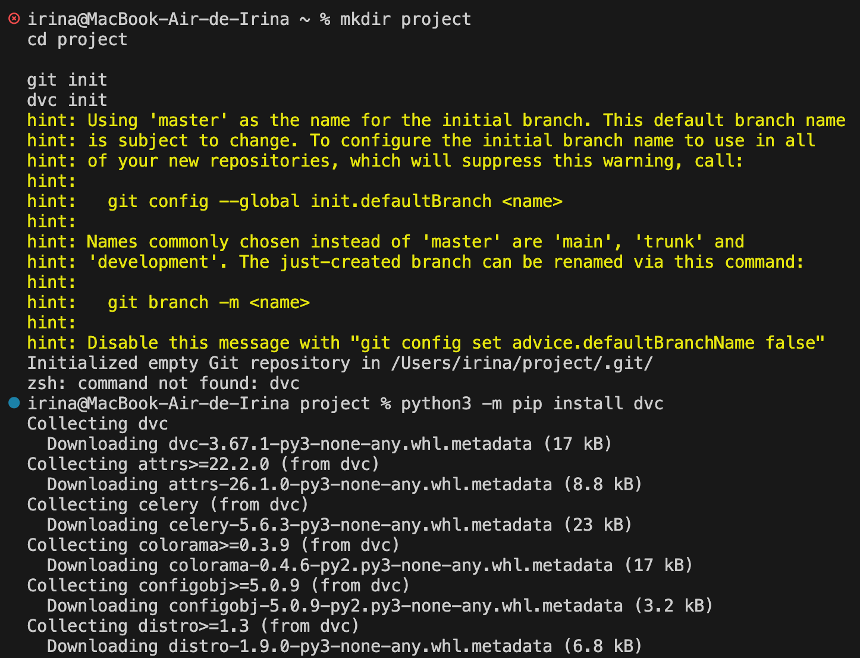

Инициализировала DVC

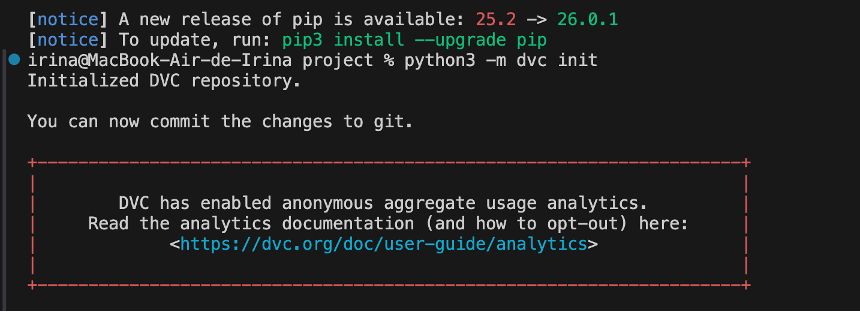

Создала структуру проекта и сделала тестовую базу

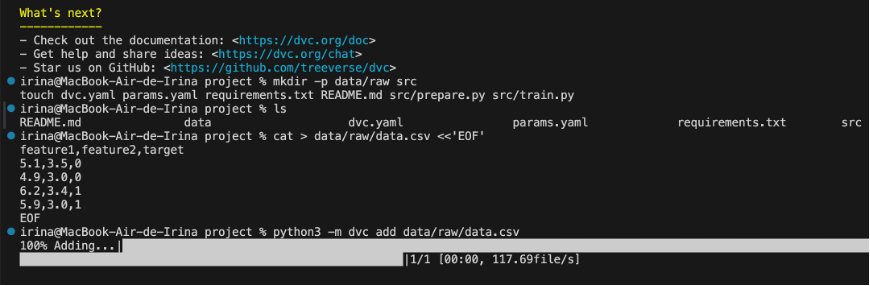

добавила тестовую базу и установила Scikit-learn

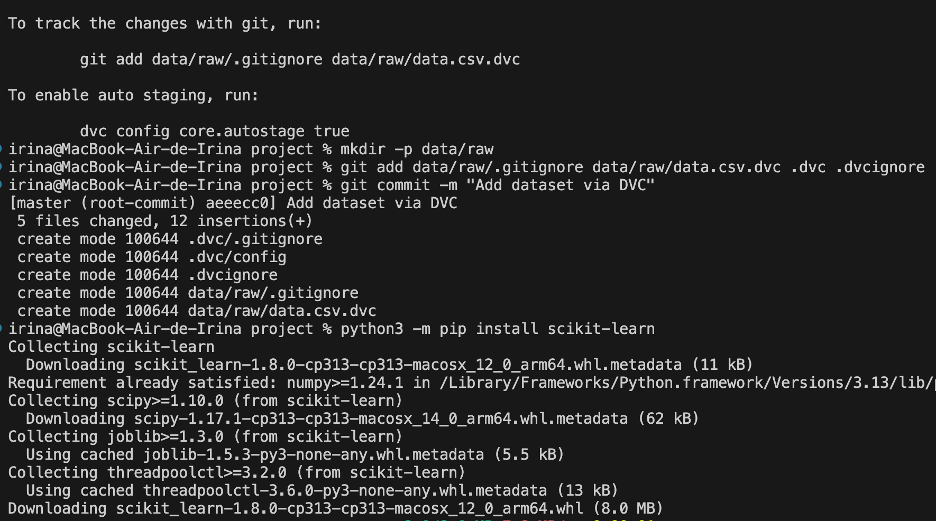


Зашрузила ирисы в DVC

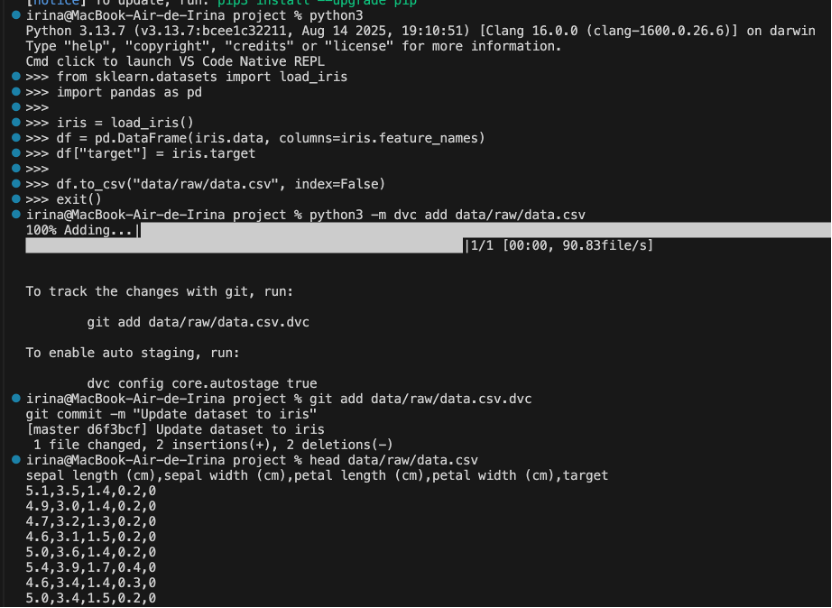

разбила на тест и трейн

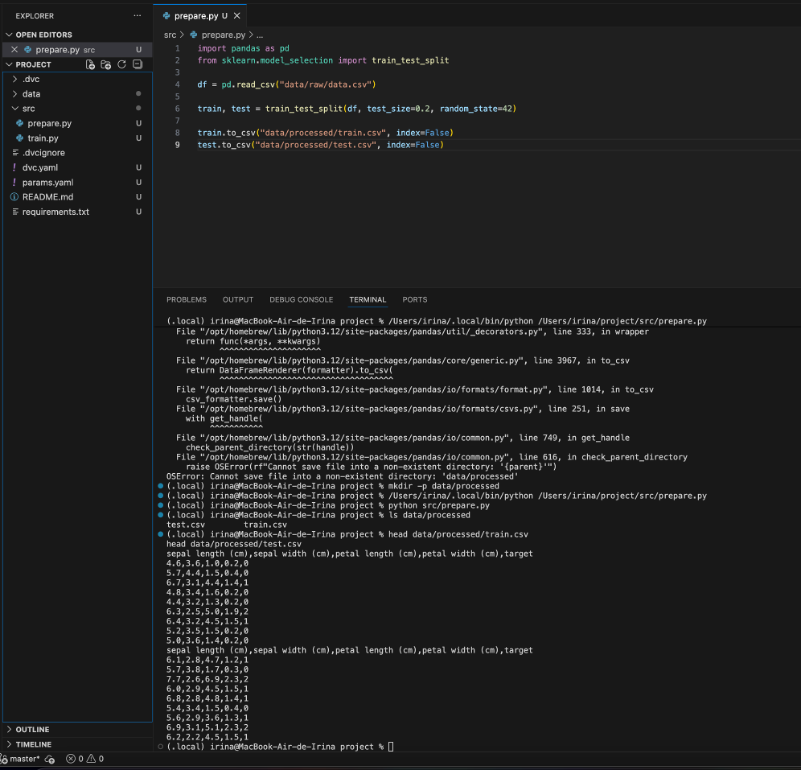

обучила модель случаного леса и сохранила модель в файл


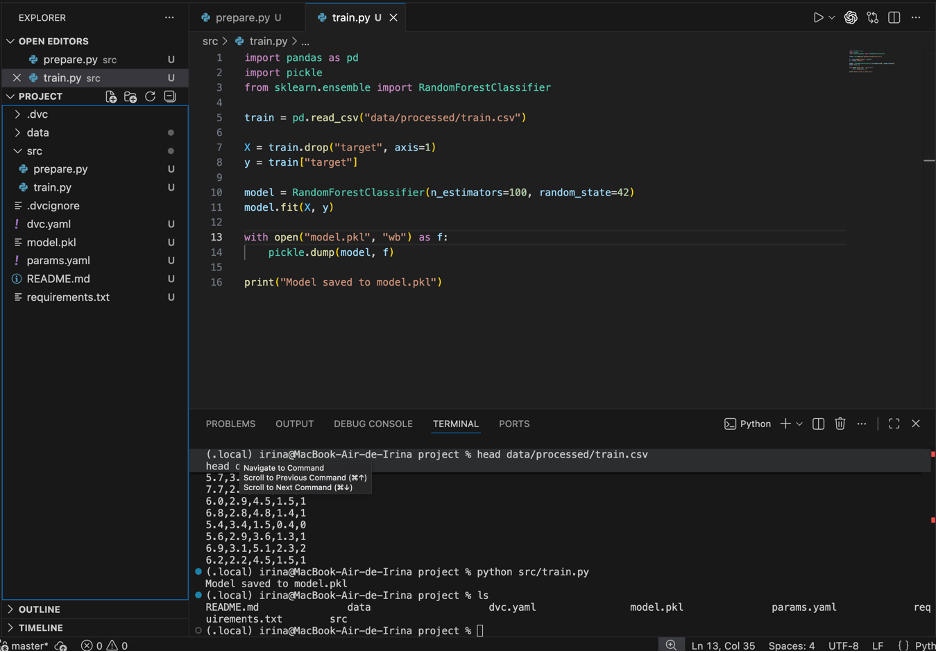

создала пайплайн prepare и test в DVC

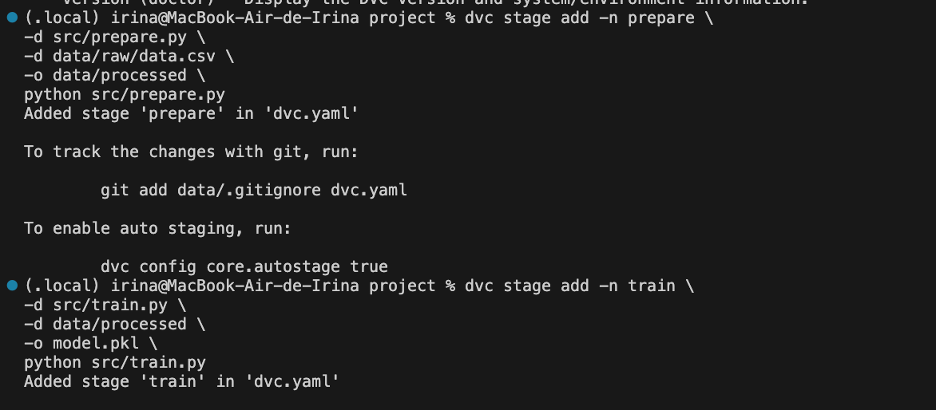

запустила и проверила пайплайн

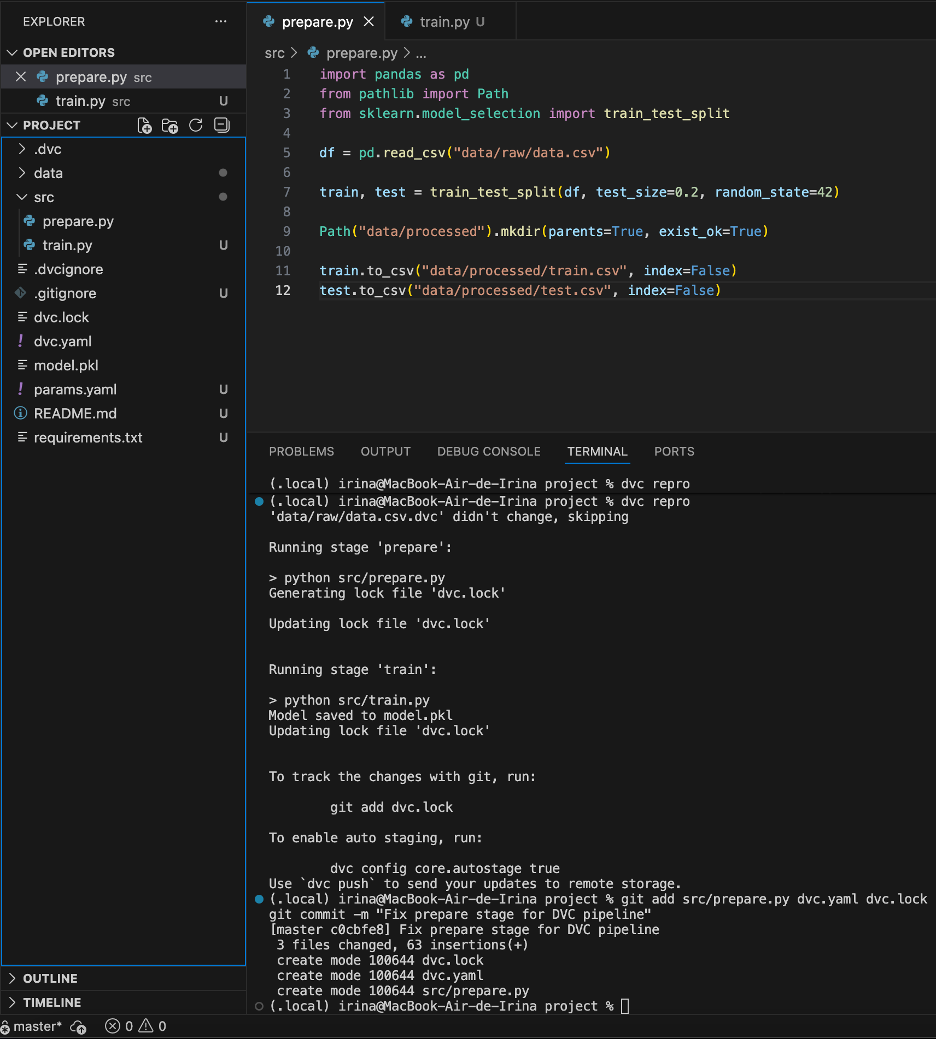

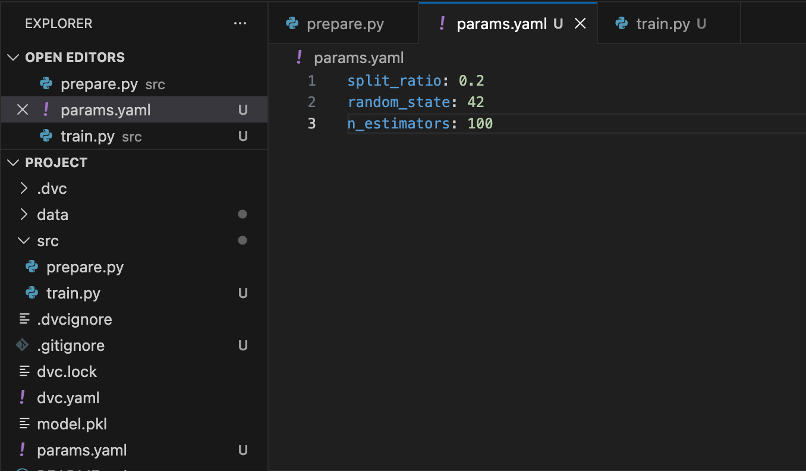

добавила params.yaml

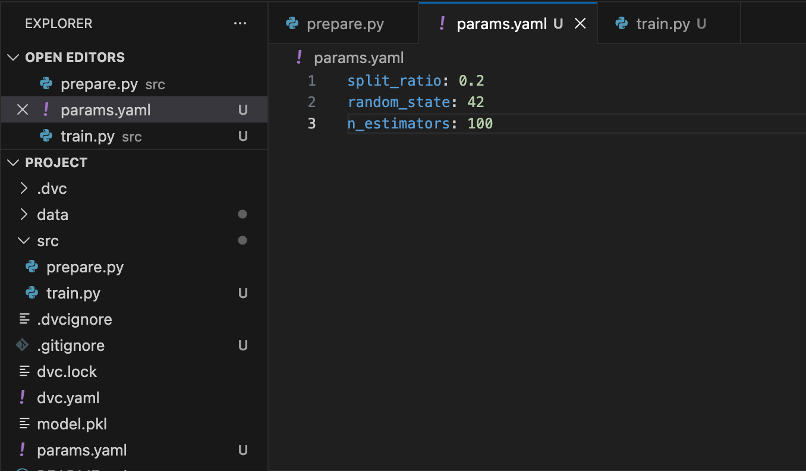

Обновила src/prepare.py  и src/train.py

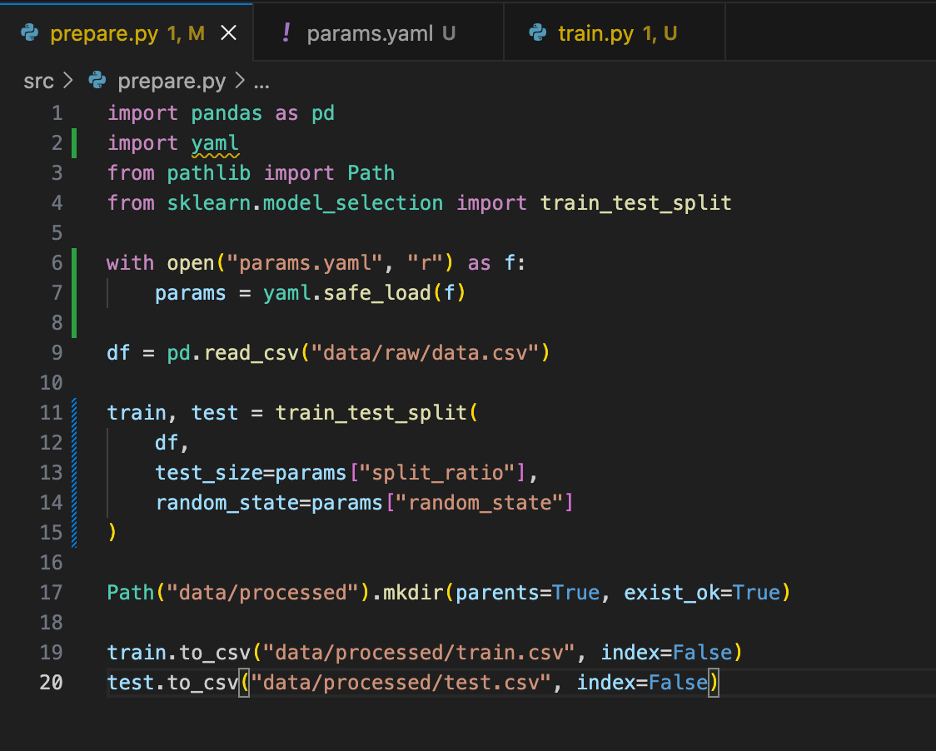

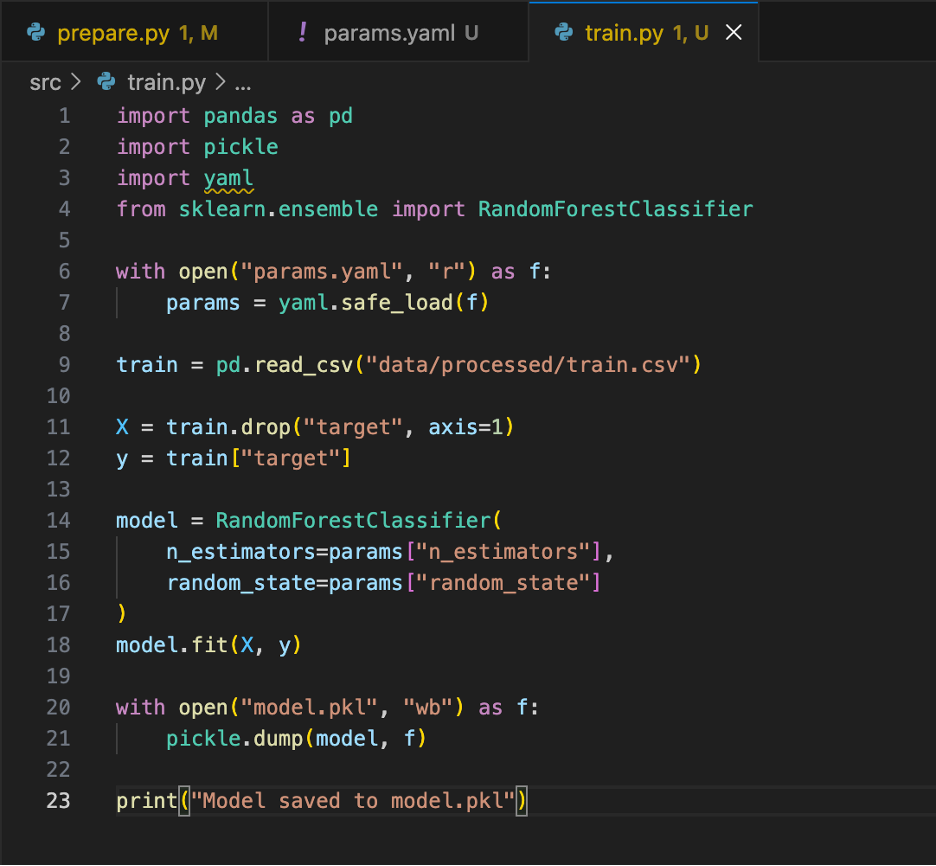

Установила pyyaml

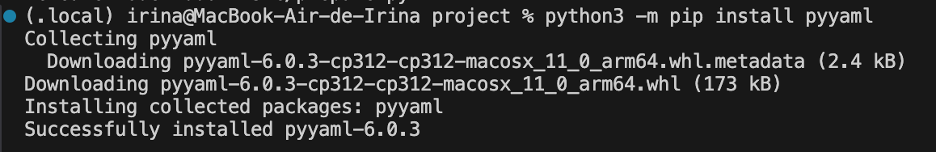

Перезаписала prepare  и train

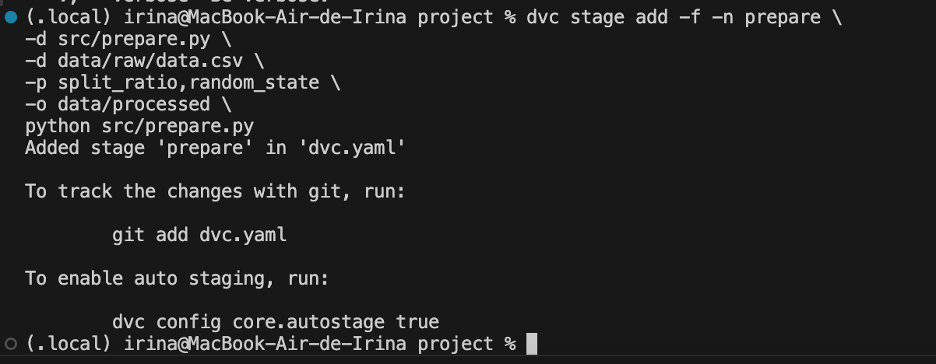

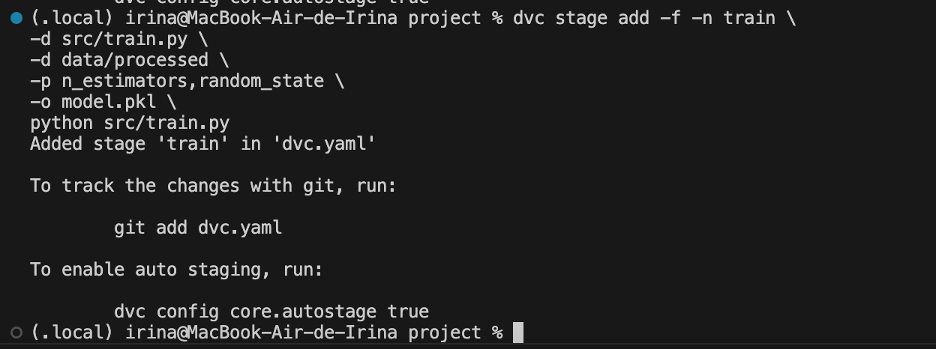

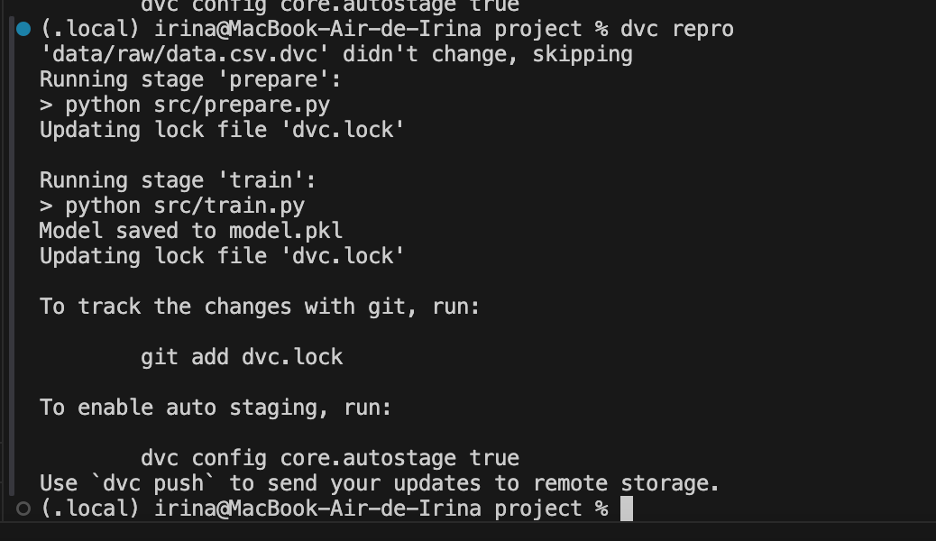

Добавиоа файл params.yaml и интеграция параметров в DVC pipeline

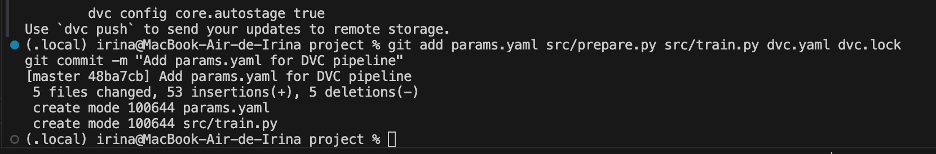

Подняла MLflow сервер

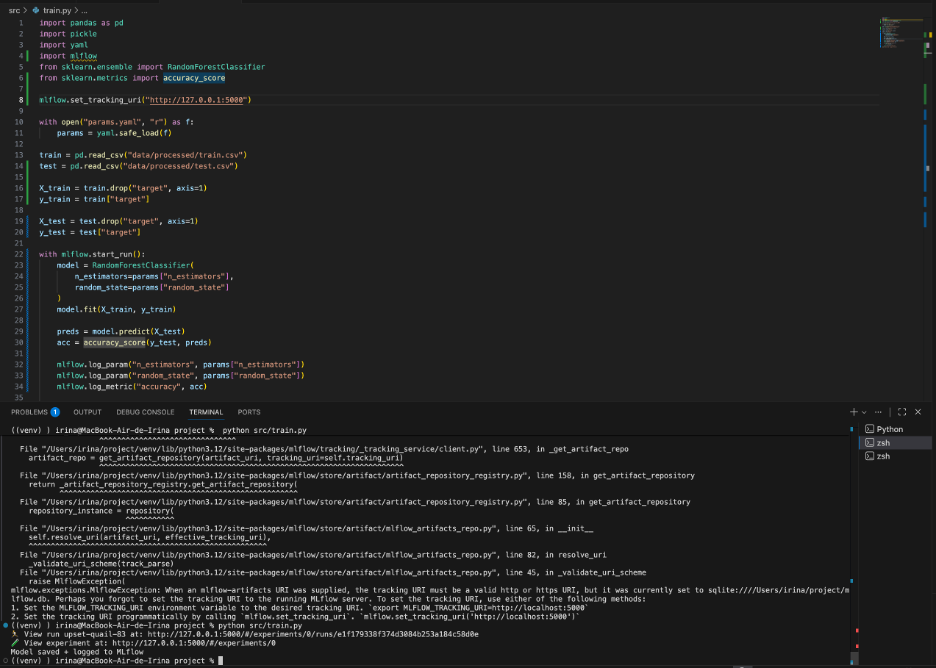

Прописала логирование в коде, все запускается

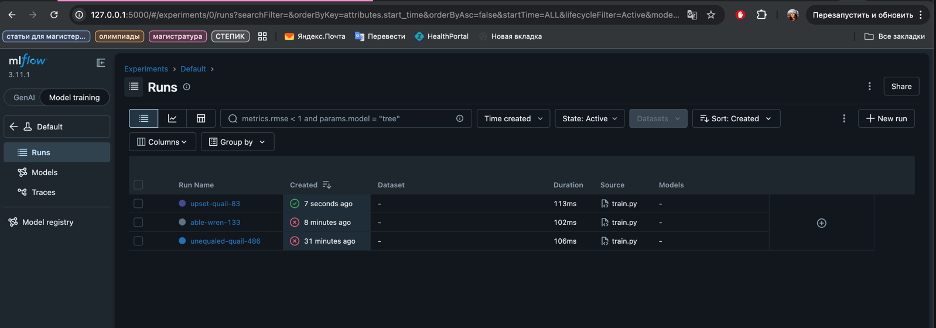

Артефакты работы в UI

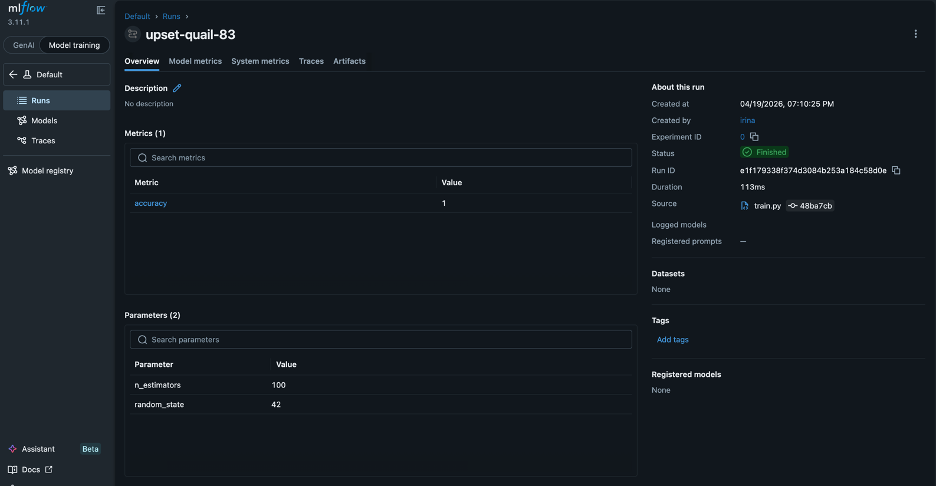

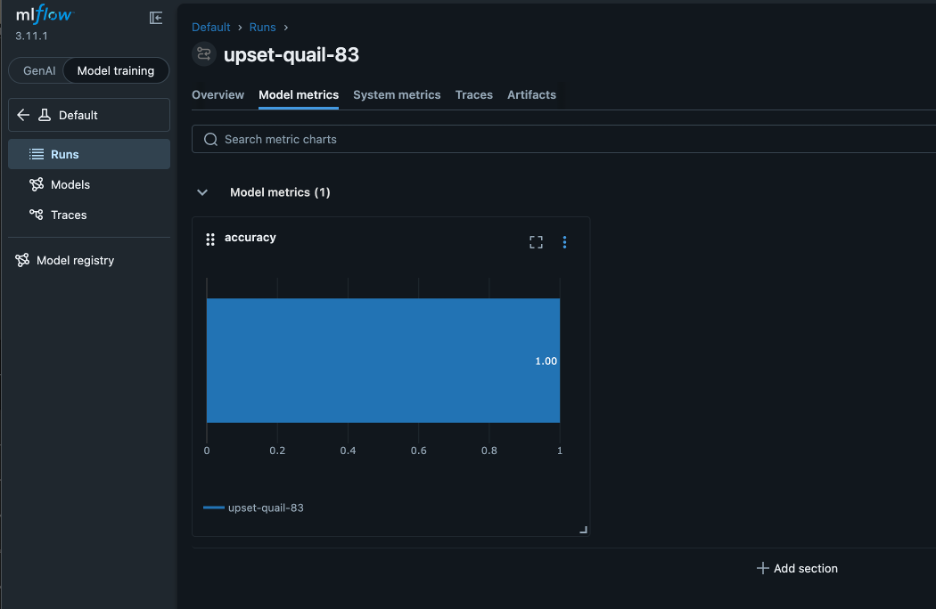

## 3. Создать хранилище признаков (Feature Store)

Используйте материалы [семинара](https://colab.research.google.com/drive/1TNd3m8-rPrTx1OjRmCnOxUGFueLbXyfe?usp=sharing), чтобы создать хранилище признаков на основе шаблона ```--template [local или postgres]```

Нужно сконфигурировать хранилище признаков в yaml-файле.

*Ожидаемый артефакт: yaml-файл в [ячейке](#scrollTo=8U4_UBuI52-j)*


In [5]:
!feast init --help
!feast init local_repo --template local

/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:64: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  prop = Group((name + Suppress("=") + comma_separated(value)) | oneOf(_CONSTANTS))
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:45: PyparsingDeprecationWarning: 'enablePackrat' deprecated - use 'enable_packrat'
  ParserElement.enablePackrat()
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'parseString' deprecated - use 'parse_string'
In /usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/stylelib/classic.mplstyle: 'reset

In [6]:
# # %load /content/local_repo/feature_repo/feature_store.yaml
# project: local_repo
# # By default, the registry is a file (but can be turned into a more scalable SQL-backed registry)
# registry: data/registry.db
# # The provider primarily specifies default offline / online stores & storing the registry in a given cloud
# provider: local
# online_store:
#     type: sqlite
#     path: data/online_store.db
# entity_key_serialization_version: 3
# # By default, no_auth for authentication and authorization, other possible values kubernetes and oidc. Refer the documentation for more details.
# auth:
#     type: no_auth


Это я тоже сначала сделала локально и залила на гит, поэтому склонирую сюда что бы показать что работы была сделана

In [7]:
!git clone https://github.com/germionna1990/hw5_mlops_dvoryashina_irina.git
%cd hw5_mlops_dvoryashina_irina

fatal: destination path 'hw5_mlops_dvoryashina_irina' already exists and is not an empty directory.
/content/hw5_mlops_dvoryashina_irina


In [8]:
with open("feature_repo/feature_store.yaml", "r") as f:
    print(f.read())

project: iris_feature_store
provider: local
registry: registry.db

online_store:
  path: online_store.db

entity_key_serialization_version: 2


In [9]:
# # %load feature_repo/feature_store.yaml
# project: iris_feature_store
# provider: local
# registry: registry.db

# online_store:
#   path: online_store.db

# entity_key_serialization_version: 2

In [10]:
# %%writefile /content/local_repo/feature_repo/feature_store.yaml

In [11]:
# %%bash
# yamllint /content/local_repo/feature_repo/feature_store.yaml

In [12]:
# print(f"Скопируйте адрес Public address, вставьте его в адресную строку браузера, нажмите Enter")
# !sleep 15 & feast ui --host 0.0.0.0 --port 8889 & tuna http 8889 & wait

## 4. Обосновать готовность ML-системы к развертыванию в продуктивном окружении

В этом домашнем задании вы сохраняли разные версии данных, создали хранилище признаков для своей ML-системы.

Насколько ML-система готова к развёртыванию?


*Ожидаемый артефакт: текст в текстовой [ячейке](#scrollTo=krw6DKDuXtHR)*





Вывод о готовности ML-системы к развёртыванию при наличии версионирования данных и наличии хранилища признаков

## 5. Разработать схему ML-системы для размытия (заблюривания) лиц на изображениях

**Вводные данные от бизнеса: нужно удалить биометрию клиентов с видео, и пример видеоданных.**

*КоАП РФ Статья 13.11.3 Непринятие организационных и технических мер по обеспечению безопасности биометрических персональных данных <...> - влечет наложение административного штрафа на должностных лиц в размере от трехсот тысяч до пятисот тысяч рублей; на юридических лиц - от одного миллиона до одного миллиона пятисот тысяч рублей.*

Нужно ознакомиться с нижеприведенным кодом, осознать что он синхронный и однопоточный, подумать как можно использовать параллелизм данных, выбрать оптимальную архитектуру и составить схематическое описание  ML-системы с помощью библиотеки Diagrams.

*Ожидаемый артефакт: схематическое описание  ML-системы [ячейке](#scrollTo=gggJafKOYvGx)*

In [20]:
import gdown; from IPython.display import Video, Image
gdrive_url = 'https://drive.google.com/uc?export=download&id=1OjSrdAS4zVfa1u7vtyh48PKEoVW20vPN'
gdown.download(gdrive_url, quiet=True); Video("/content/HW5_Woman_Happy.mp4",embed=True, width=640, height=360)

In [ ]:
# gdrive_url = 'https://drive.google.com/uc?export=download&id=1UEEF9GIVaO2mRKxVFIaU2Dn1Jjnj7-OU'
# gdown.download(gdrive_url, quiet=True); Image("/content/HW5_Woman_Happy_blurred.gif",embed=True, width=640, height=360)

Не отрабатывал гугл файл, поэтому разбила на шаги

Downloading...
From: https://drive.google.com/uc?export=download&id=1UEEF9GIVaO2mRKxVFIaU2Dn1Jjnj7-OU
To: /content/hw5_mlops_dvoryashina_irina/HW5_Woman_Happy_blurred.gif
100%|██████████| 2.06M/2.06M [00:00<00:00, 15.4MB/s]


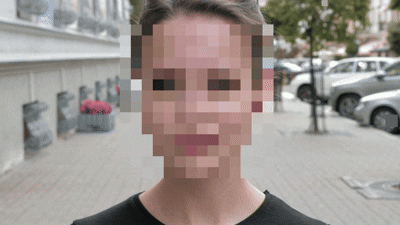

In [19]:
file_path = gdown.download(gdrive_url, quiet=False)
Image(file_path)

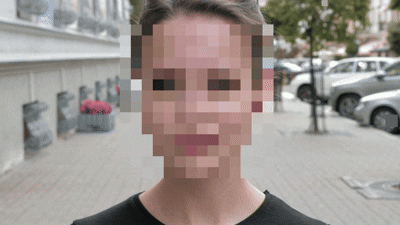

In [22]:
Image('/content/hw5_mlops_dvoryashina_irina/HW5_Woman_Happy_blurred.gif', width=640)

%%html

Нижеприведенный код ML-системы обрабатывает каждый кадр видео так:

<table >
		<tr>
			<td>
      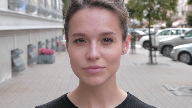
      </td>
      <td>
      <font size="96px">
      &#10145;</font>
      </td>
			<td>
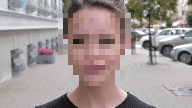
</td>
		</tr>
</table>

In [18]:
from diagrams import Diagram, Cluster
from diagrams.onprem.client import User
from diagrams.onprem.queue import Kafka
from diagrams.onprem.compute import Server
from diagrams.onprem.inmemory import Redis
from diagrams.onprem.workflow import Airflow
from diagrams.onprem.monitoring import Prometheus, Grafana
from diagrams.aws.storage import S3
from diagrams.programming.language import Python

with Diagram(
    "ML система для блюра лиц",
    filename="face_blur_ml_system",
    show=True,
    direction="LR",
):

    business = User("Бизнес / оператор")

    raw_storage = S3("Raw video storage")
    result_storage = S3("Blurred video storage")

    orchestrator = Airflow("Оркестратор")
    splitter = Python("Split video")
    assembler = Python("Assemble video")

    queue = Kafka("Task queue")
    cache = Redis("Metadata / cache")

    with Cluster("Workers (parallel processing)"):
        worker1 = Server("Worker 1")
        worker2 = Server("Worker 2")
        worker3 = Server("Worker 3")

    with Cluster("ML внутри worker"):
        detector = Python("Face detection")
        blur = Python("Blur faces")

    monitor = Prometheus("Monitoring")
    dashboard = Grafana("Dashboard")

    # pipeline
    business >> raw_storage >> orchestrator >> splitter >> queue

    queue >> worker1
    queue >> worker2
    queue >> worker3

    worker1 >> detector >> blur
    worker2 >> detector >> blur
    worker3 >> detector >> blur

    worker1 >> cache
    worker2 >> cache
    worker3 >> cache

    cache >> assembler >> result_storage

    orchestrator >> monitor
    worker1 >> monitor
    worker2 >> monitor
    worker3 >> monitor
    monitor >> dashboard

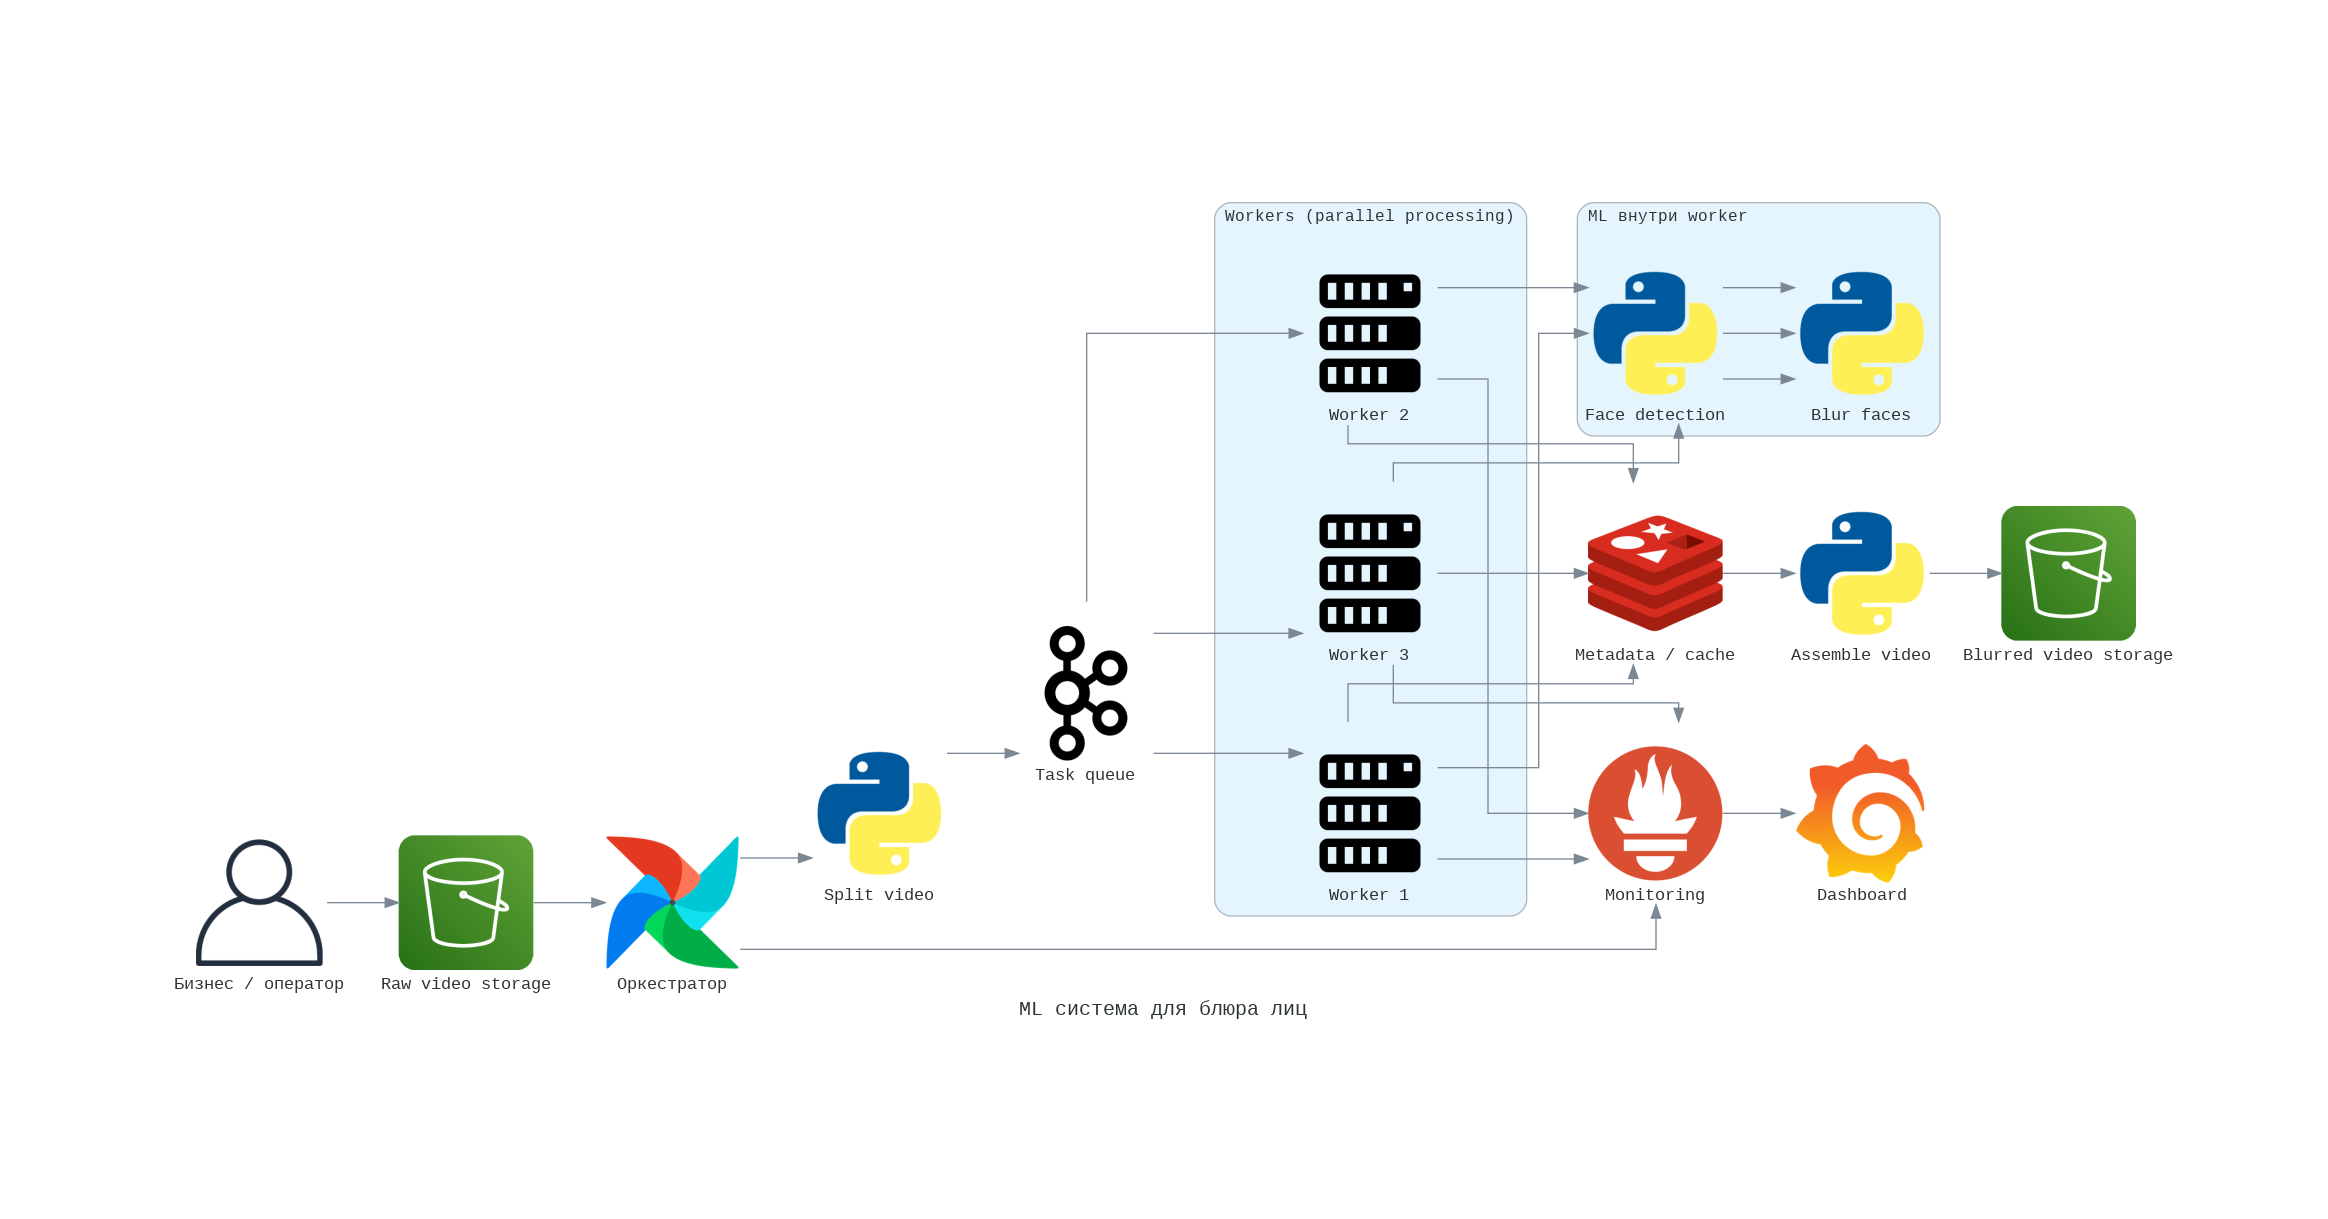

In [16]:
from IPython.display import Image, display
display(Image("face_blur_ml_system.png"))

диаграмма ML-системы

## 6. Итоговое оформление

В итоговых выводах дайте 5–8 предложений о своем опыте работы с инструментами модуля: что оказалось простым, что вызвало трудности, какие выводы сделали о воспроизводимости эксперимента c DVC/MLflow в реальных проектах.

